In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import linalg as la

1\. **PCA on 3D dataset**

* Generate a dataset with 3 features each with N entries (N being ${\cal O}(1000)$). With $N(\mu,\sigma)$ the normali distribution with mean $\mu$ and $\sigma$  standard deviation, generate the 3 variables $x_{1,2,3}$ such that:
    * $x_1$ is distributed as $N(0,1)$
    * $x_2$ is distributed as $x_1+N(0,3)$
    * $x_3$ is given by $2x_1+x_2$

In [2]:
N = 1000

x1 = np.random.normal(0, 1, size = N)
x2 = x1 + np.random.normal(0, np.sqrt(3), size = N)
x3 = 2*x1 + x2

X = np.column_stack((x1, x2, x3)).T
print(X)

[[-0.52306496 -0.3142934   0.1926284  ... -0.06312872 -1.66394904
   0.62677875]
 [-0.96981357  2.10233868 -0.98459251 ... -0.96990053 -1.75326596
  -0.60040618]
 [-2.01594349  1.47375189 -0.59933571 ... -1.09615797 -5.08116403
   0.65315132]]


* Find the eigenvectors and eigenvalues of the covariance matrix of the dataset

In [3]:
# using eigen decomposition
cov = np.cov(X) #takes the transpose
print(f"Covariance matrix: \n {cov} \n")

l, V = la.eig(cov)
l = np.real_if_close(l)
Lambda = np.diag(l)
print(f"Eigenvalues: \n {l} \n")
print(f"Diagonal matrix: \n {Lambda} \n")
print(f"Eigenvectors: \n v1 = {V[:,0]} \n v2 = {V[:,1]} \n v3 = {V[:,2]}")

Covariance matrix: 
 [[ 1.09018085  1.13895296  3.31931467]
 [ 1.13895296  4.13168084  6.40958677]
 [ 3.31931467  6.40958677 13.0482161 ]] 

Eigenvalues: 
 [1.71479374e+01 1.08649413e-15 1.12214037e+00] 

Diagonal matrix: 
 [[1.71479374e+01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.08649413e-15 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.12214037e+00]] 

Eigenvectors: 
 v1 = [-0.21139142 -0.44661353 -0.86939636] 
 v2 = [-0.81649658 -0.40824829  0.40824829] 
 v3 = [ 0.53725879 -0.79615934  0.27835823]


* Find the eigenvectors and eigenvalues using SVD. Check that the two procedures yield to same result

In [4]:
# using SVD in the square case
U, spectrum, Vt = la.svd(cov)
spectrum = np.real_if_close(spectrum)
print(f"Eigenvalues: \n {spectrum} \n")
print(f"Diagonal matrix: \n {np.diag(spectrum)} \n")
print(f"Eigenvectors: \n v1 = {U[:,0]} \n v2 = {U[:,1]} \n v3 = {U[:,2]}")

# same result but permutated

Eigenvalues: 
 [1.71479374e+01 1.12214037e+00 1.72779663e-15] 

Diagonal matrix: 
 [[1.71479374e+01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.12214037e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.72779663e-15]] 

Eigenvectors: 
 v1 = [-0.21139142 -0.44661353 -0.86939636] 
 v2 = [ 0.53725879 -0.79615934  0.27835823] 
 v3 = [-0.81649658 -0.40824829  0.40824829]


* What percent of the total dataset's variability is explained by the principal components? Given how the dataset was constructed, do these make sense? Reduce the dimensionality of the system so that at least 99% of the total variability is retained.

In [5]:
print ("Cov.trace():", np.cov(X).trace(), "\n") # sum of the diagonal

print (f"{np.abs(Lambda[0,0]/Lambda.trace())} % of variability")
print (f"{np.abs(Lambda[1,1]/Lambda.trace())} % of variability")
print (f"{np.abs(Lambda[2,2]/Lambda.trace())} % of variability")

Cov.trace(): 18.270077794926607 

0.938580427142226 % of variability
5.94685004418086e-17 % of variability
0.0614195728577739 % of variability


/tmp/ipykernel_15946/1793967920.py:11: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot([0, scale_factor * li * vi[0]],


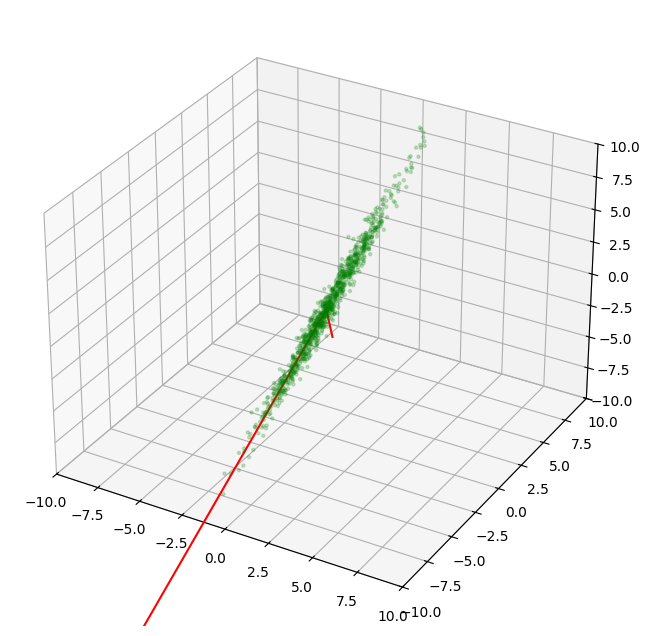

In [6]:
fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(projection='3d')
scale_factor = 4

# 1. Plot the scatter data
ax.scatter(X[0,:], X[1,:], X[2,:], alpha=0.2, color='green', marker='.')

# 2. Plot the vectors using the 3D axis object 'ax'
for li, vi in zip(l, V.T):
    # We need: [x_start, x_end], [y_start, y_end], [z_start, z_end]
    ax.plot([0, scale_factor * li * vi[0]], 
            [0, scale_factor * li * vi[1]], 
            [0, scale_factor * li * vi[2]],  # Missing Z-component
            'r-', lw=1.5, color='red')

ax.set_xlim([-10, 10])
ax.set_ylim([-10, 10])
ax.set_zlim([-10, 10])
plt.show()

* Redefine the data in the basis yielded by the PCA procedure

/tmp/ipykernel_15946/3659782984.py:13: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "r-" (-> color='r'). The keyword argument will take precedence.
  ax.plot([0, scale_factor * li * vi[0]],


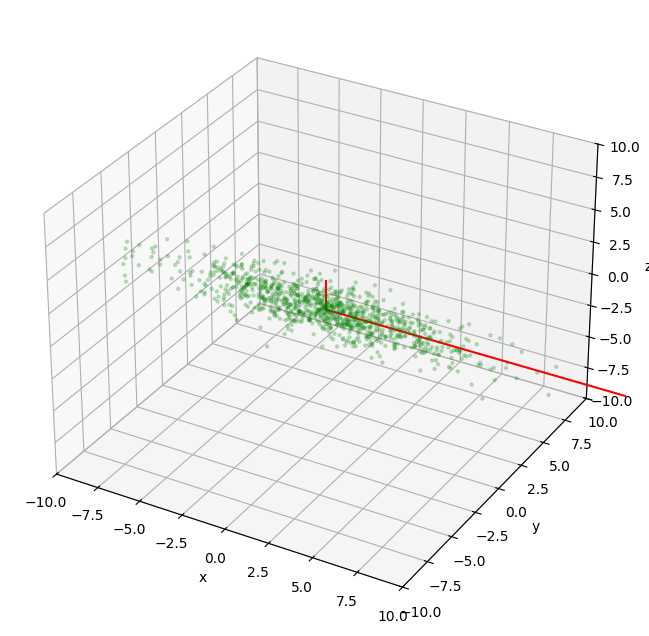

In [7]:
Xp = np.dot(V.T, X)

fig = plt.figure(figsize = (8,8))
ax = fig.add_subplot(projection='3d')
scale_factor = 2

# 1. Plot the scatter data
ax.scatter(Xp[0,:], Xp[1,:], Xp[2,:], alpha=0.2, color='green', marker='.')

# 2. Plot the vectors using the 3D axis object 'ax'
for li, vi in zip(l, np.diag([1]*3)):
    # We need: [x_start, x_end], [y_start, y_end], [z_start, z_end]
    ax.plot([0, scale_factor * li * vi[0]], 
            [0, scale_factor * li * vi[1]], 
            [0, scale_factor * li * vi[2]],  # Missing Z-component
            'r-', lw=1.5, color='red')

ax.set_xlim([-10, 10])
ax.set_ylim([-10, 10])
ax.set_zlim([-10, 10])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
plt.show()

In [8]:
Xredp = np.column_stack((Xp[0,:], np.zeros(N), Xp[2,:])).T
# using eigen decomposition
covred = np.cov(Xredp) #takes the transpose
print(f"Covariance matrix: \n {cov} \n")

l, Vred = la.eig(cov)
l = np.real_if_close(l)
Lambda = np.diag(l)
print(f"Eigenvalues: \n {l} \n")
print(f"Diagonal matrix: \n {Lambda} \n")
print(f"Eigenvectors: \n v1 = {Vred[:,0]} \n v2 = {Vred[:,1]} \n v3 = {Vred[:,2]}") # now is the identity since we have rotated to pc

Covariance matrix: 
 [[ 1.09018085  1.13895296  3.31931467]
 [ 1.13895296  4.13168084  6.40958677]
 [ 3.31931467  6.40958677 13.0482161 ]] 

Eigenvalues: 
 [1.71479374e+01 1.08649413e-15 1.12214037e+00] 

Diagonal matrix: 
 [[1.71479374e+01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 1.08649413e-15 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 1.12214037e+00]] 

Eigenvectors: 
 v1 = [-0.21139142 -0.44661353 -0.86939636] 
 v2 = [-0.81649658 -0.40824829  0.40824829] 
 v3 = [ 0.53725879 -0.79615934  0.27835823]


In [9]:
print ("Cov.trace():", np.cov(X).trace(), "\n") # sum of the diagonal

print (f"{np.abs(Lambda[0,0]/Lambda.trace())} % of variability")
print (f"{np.abs(Lambda[1,1]/Lambda.trace())} % of variability")

Cov.trace(): 18.270077794926607 

0.938580427142226 % of variability
5.94685004418086e-17 % of variability


* Plot the data points in the original and the new coordiantes as a set of scatter plots. Your final figure should have 2 rows of 3 plots each, where the columns show the (0,1), (0,2) and (1,2) proejctions.

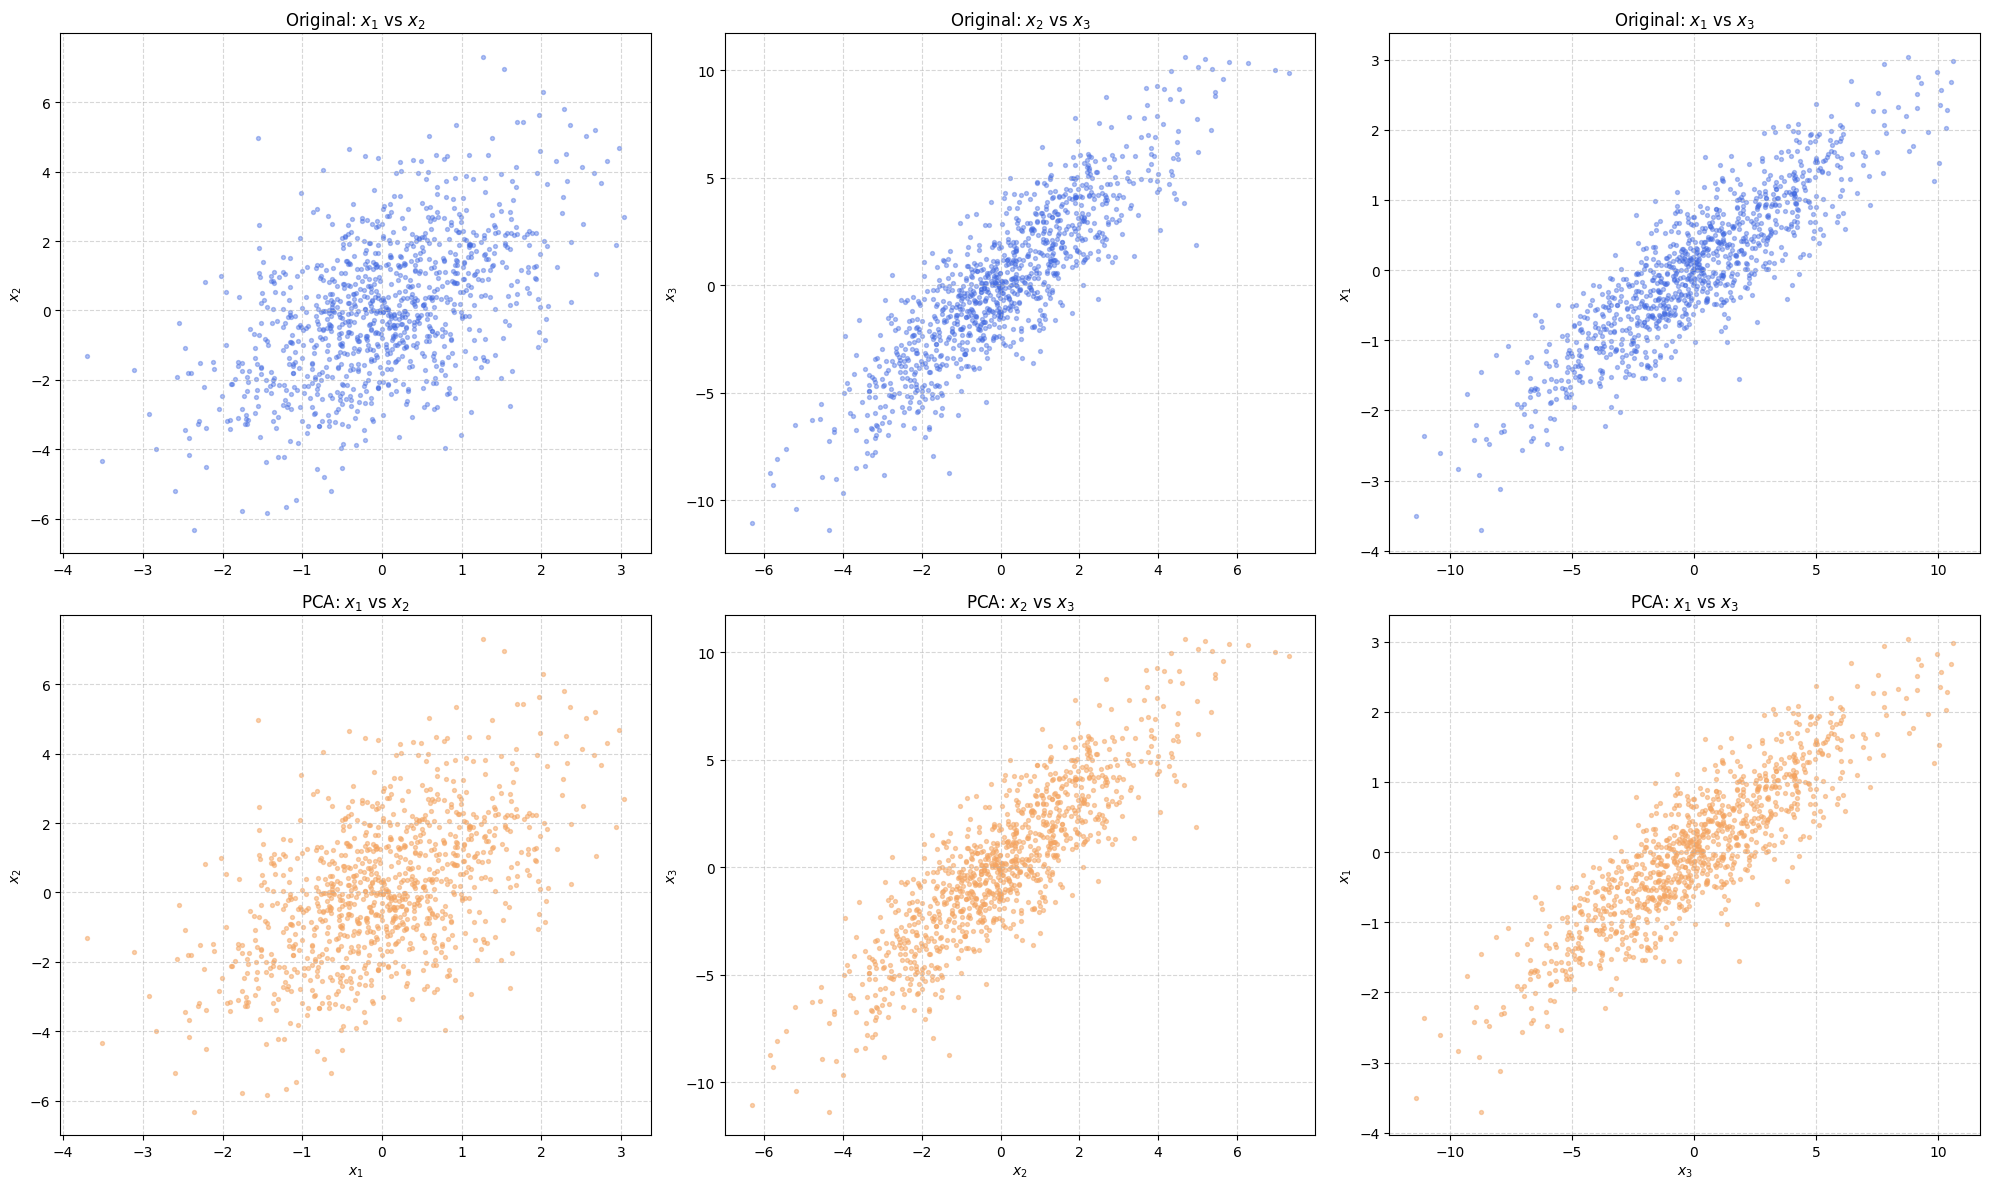

In [10]:
Xred = np.dot(V, Xredp) # Xred = V * red(Vt * X)

fig, ax = plt.subplots(2, 3, figsize=(20, 12))

ax[0,0].scatter(X[0,:], X[1,:], alpha=0.4, s=8, color='royalblue')
ax[0,0].set_title("Original: $x_1$ vs $x_2$")
ax[0,0].set_ylabel("$x_2$")

ax[0,1].scatter(X[1,:], X[2,:], alpha=0.4, s=8, color='royalblue')
ax[0,1].set_title("Original: $x_2$ vs $x_3$")
ax[0,1].set_ylabel("$x_3$")

ax[0,2].scatter(X[2,:], X[0,:], alpha=0.4, s=8, color='royalblue')
ax[0,2].set_title("Original: $x_1$ vs $x_3$")
ax[0,2].set_ylabel("$x_1$")

Z = Xred
ax[1,0].scatter(Z[0,:], Z[1,:], alpha=0.5, s=8, color='sandybrown')
ax[1,0].set_title("PCA: $x_1$ vs $x_2$")
ax[1,0].set_xlabel("$x_1$")
ax[1,0].set_ylabel("$x_2$")

ax[1,1].scatter(Z[1,:], Z[2,:], alpha=0.5, s=8, color='sandybrown')
ax[1,1].set_title("PCA: $x_2$ vs $x_3$")
ax[1,1].set_xlabel("$x_2$")
ax[1,1].set_ylabel("$x_3$")

ax[1,2].scatter(Z[2,:], Z[0,:], alpha=0.5, s=8, color='sandybrown')
ax[1,2].set_title("PCA: $x_1$ vs $x_3$")
ax[1,2].set_xlabel("$x_3$")
ax[1,2].set_ylabel("$x_1$")


for a in ax.flat:
    a.grid(True, linestyle='--', alpha=0.5)

#ax[0, 0].set_visible(False)
#ax[1, 0].set_visible(False)
#ax[1, 1].set_visible(False)

plt.tight_layout()
plt.show()

2\. **PCA on a nD dataset**

Start from the dataset you have genereted in the previous exercise and add uncorrelated random noise. Such noise should be represented by other 10 uncorrelated variables normal distributed, with standar deviation much smaller (say, a factor 50) than those used to generate the $x_1$ and $x_2$.

Repeat the PCA procedure and compare the results with what you obtained before

In [11]:
# Assuming N is your number of samples (e.g., 1000)
# Original variables from previous step:
# x1 = np.random.normal(0, 1, N)
# x2 = x1 + np.random.normal(0, np.sqrt(3), N)
# x3 = 2*x1 + x2
# X = np.array([x1, x2, x3])

# 1. Generate 10 uncorrelated noise variables
noise_std = 1.0 / 50
noise_variables = np.random.normal(0, noise_std, size=(10, N))

# 2. Concatenate with original 3 variables
Xprime = np.vstack((X, noise_variables))

In [12]:
# using eigen decomposition
cov = np.cov(Xprime) #takes the transpose
print(f"Covariance matrix: \n {cov} \n")

l, V = la.eig(cov)
l = np.real_if_close(l)
Lambda = np.diag(l)
print(f"Eigenvalues: \n {l} \n")
print(f"Diagonal matrix: \n {Lambda} \n")

Covariance matrix: 
 [[ 1.09018085e+00  1.13895296e+00  3.31931467e+00  4.84178414e-04
  -8.35370484e-04  2.25610523e-04  1.51288941e-03  1.14451626e-04
   1.32818675e-03 -6.60219282e-04  5.83949822e-04  5.77608659e-04
  -7.73783104e-04]
 [ 1.13895296e+00  4.13168084e+00  6.40958677e+00  2.78933879e-04
   2.05338962e-04  6.33583299e-04  1.22855171e-03 -6.26322007e-05
   1.50578995e-04 -1.10280797e-03  1.98654998e-03 -1.29201707e-03
  -6.33876580e-04]
 [ 3.31931467e+00  6.40958677e+00  1.30482161e+01  1.24729071e-03
  -1.46540201e-03  1.08480435e-03  4.25433054e-03  1.66271052e-04
   2.80695249e-03 -2.42324653e-03  3.15444963e-03 -1.36799748e-04
  -2.18144279e-03]
 [ 4.84178414e-04  2.78933879e-04  1.24729071e-03  4.19282176e-04
   8.61878223e-06  4.15298560e-06 -1.78007861e-06  3.65587246e-06
   2.12543812e-07 -1.84131010e-05 -7.40590325e-07 -1.66662987e-05
   8.11154668e-08]
 [-8.35370484e-04  2.05338962e-04 -1.46540201e-03  8.61878223e-06
   3.74152504e-04 -1.32828770e-06 -9.44003951

In [13]:
print ("Cov.trace():", np.cov(X).trace(), "\n") # sum of the diagonal

for i in range(13):
    print (f"{np.abs(Lambda[i,i]/Lambda.trace()):.17f} % of variability")

Cov.trace(): 18.270077794926607 

0.93837614857148999 % of variability
0.06140649894870830 % of variability
0.00000000000000007 % of variability
0.00001723199932470 % of variability
0.00002587244486138 % of variability
0.00002482228995161 % of variability
0.00001937058841376 % of variability
0.00001968217790222 % of variability
0.00002035614614690 % of variability
0.00002135892259600 % of variability
0.00002342417336698 % of variability
0.00002251917686832 % of variability
0.00002271456036945 % of variability


In [14]:
Xprimep = np.dot(V.T, Xprime)
Xprimeredp = np.zeros((13, N))
Xprimeredp[0, :] = Xprimep[0, :] # keep only first two components
Xprimeredp[1, :] = Xprimep[1, :] 
Xprimered = np.dot(V, Xprimeredp)

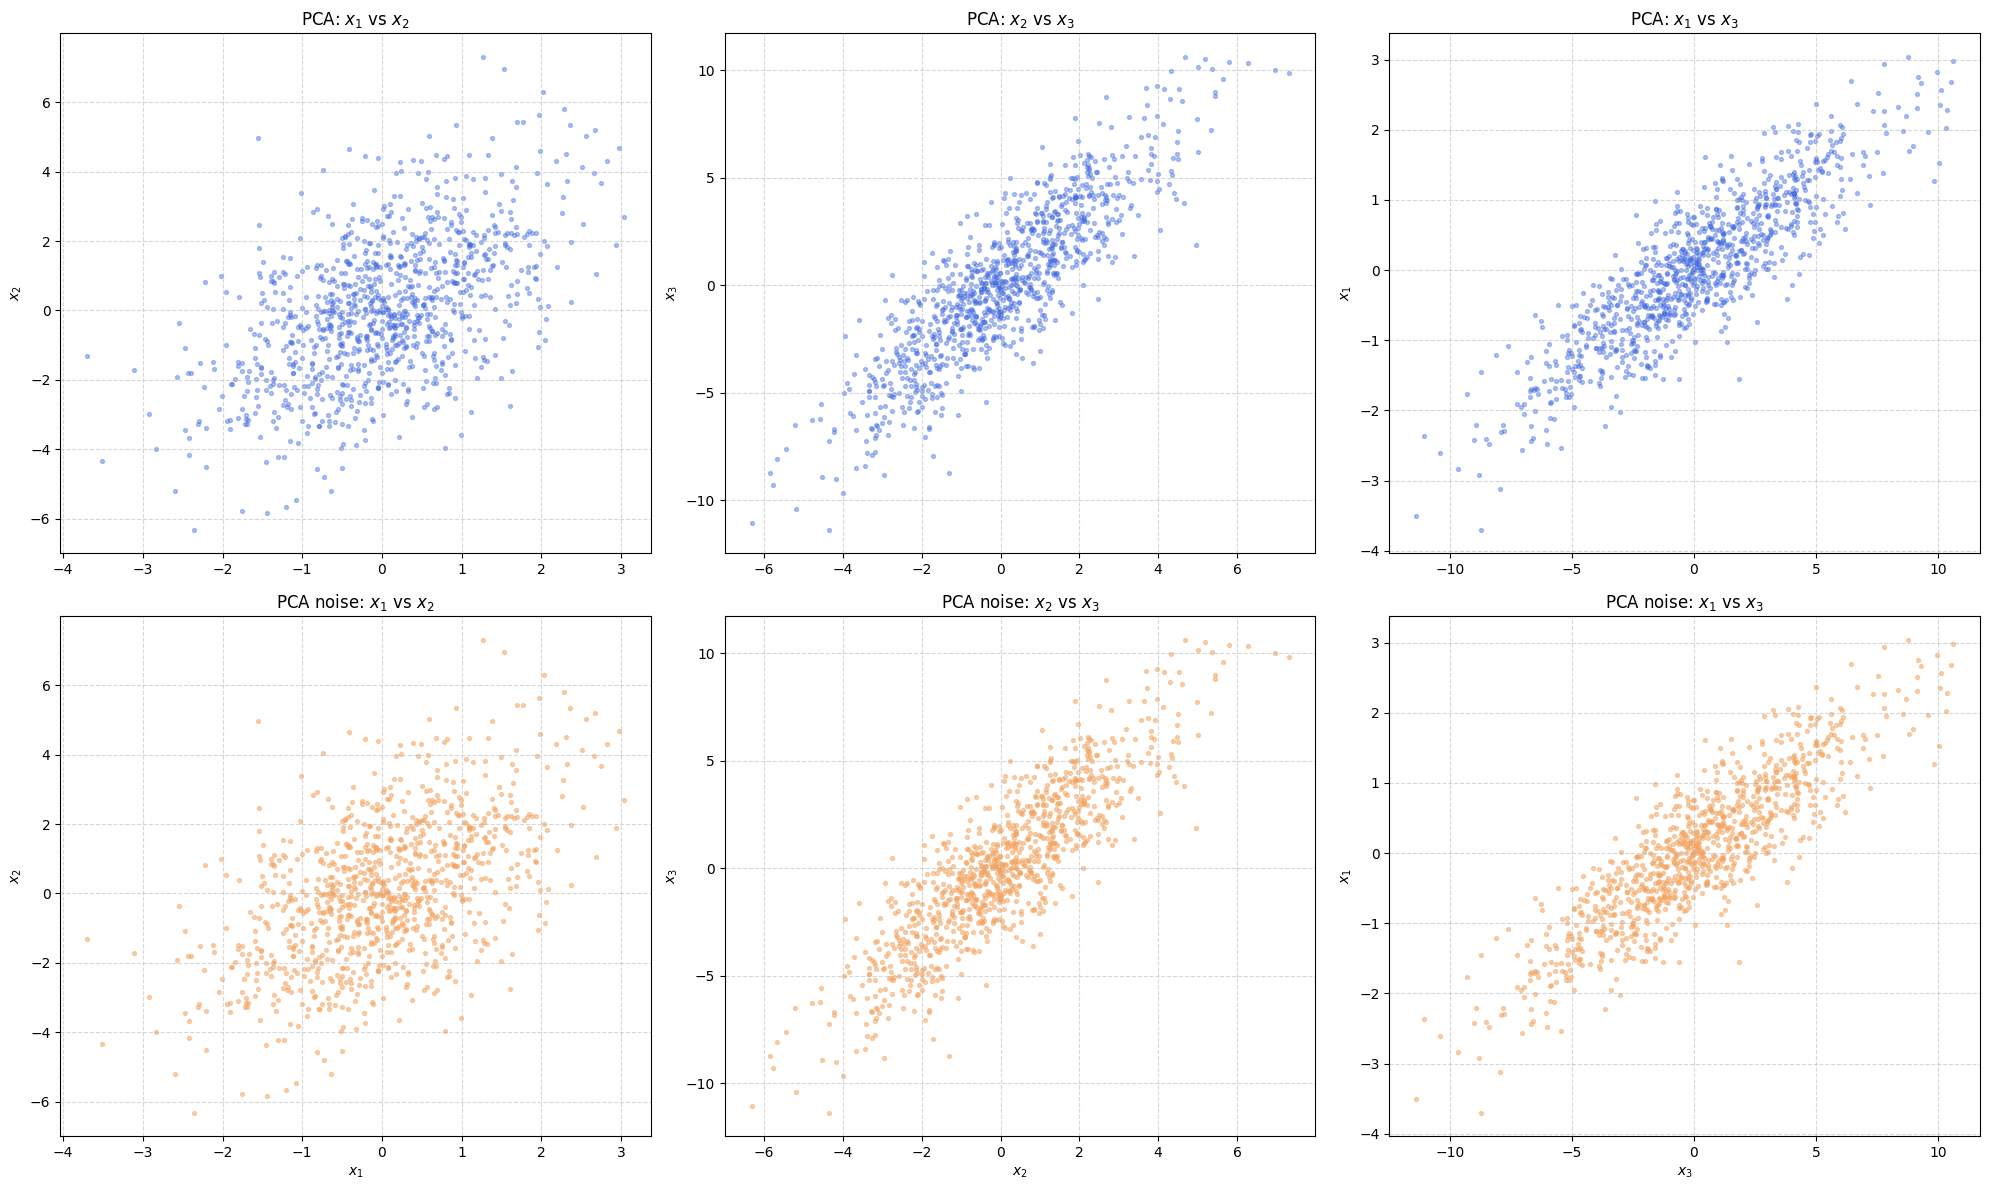

In [15]:
fig, ax = plt.subplots(2, 3, figsize=(20, 12))

ax[0,0].scatter(Xred[0,:], Xred[1,:], alpha=0.4, s=8, color='royalblue')
ax[0,0].set_title("PCA: $x_1$ vs $x_2$")
ax[0,0].set_ylabel("$x_2$")

ax[0,1].scatter(Xred[1,:], Xred[2,:], alpha=0.4, s=8, color='royalblue')
ax[0,1].set_title("PCA: $x_2$ vs $x_3$")
ax[0,1].set_ylabel("$x_3$")

ax[0,2].scatter(Xred[2,:], Xred[0,:], alpha=0.4, s=8, color='royalblue')
ax[0,2].set_title("PCA: $x_1$ vs $x_3$")
ax[0,2].set_ylabel("$x_1$")

Z = Xprimered
ax[1,0].scatter(Z[0,:], Z[1,:], alpha=0.5, s=8, color='sandybrown')
ax[1,0].set_title("PCA noise: $x_1$ vs $x_2$")
ax[1,0].set_xlabel("$x_1$")
ax[1,0].set_ylabel("$x_2$")

ax[1,1].scatter(Z[1,:], Z[2,:], alpha=0.5, s=8, color='sandybrown')
ax[1,1].set_title("PCA noise: $x_2$ vs $x_3$")
ax[1,1].set_xlabel("$x_2$")
ax[1,1].set_ylabel("$x_3$")

ax[1,2].scatter(Z[2,:], Z[0,:], alpha=0.5, s=8, color='sandybrown')
ax[1,2].set_title("PCA noise: $x_1$ vs $x_3$")
ax[1,2].set_xlabel("$x_3$")
ax[1,2].set_ylabel("$x_1$")


for a in ax.flat:
    a.grid(True, linestyle='--', alpha=0.5)

#ax[0, 0].set_visible(False)
#ax[1, 0].set_visible(False)
#ax[1, 1].set_visible(False)

plt.tight_layout()
plt.show()

3 \. **Looking at an oscillating spring** (optional)

Imagine you have $n$ cameras looking at a spring oscillating along the $x$ axis. Each  camera record the motion of the spring looking at it along a given direction defined by the pair $(\theta_i, \phi_i)$, the angles in spherical coordinates. 

Start from the simulation of the records (say ${\cal O}(1000)$) of the spring's motion along the x axis, assuming a little random noise affects the measurements along the $y$. Rotate such dataset to emulate the records of each camera.

Perform a Principal Component Analysis on the thus obtained dataset, aiming at finding the only one coordinate that really matters.


4\. **PCA on the MAGIC dataset** (optional)

Perform a PCA on the magic04.data dataset

In [16]:
# get the dataset and its description on the proper data directory
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data -P ~/data/
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.names -P ~/data/ 

Will not apply HSTS. The HSTS database must be a regular and non-world-writable file.
ERROR: could not open HSTS store at '/mnt/c/Users/kevin/.wget-hsts'. HSTS will be disabled.
--2025-12-17 12:55:34--  https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘/mnt/c/Users/kevin/data/magic04.data.6’

magic04.data.6          [      <=>           ]   1.41M  1.17MB/s    in 1.2s    

2025-12-17 12:55:36 (1.17 MB/s) - ‘/mnt/c/Users/kevin/data/magic04.data.6’ saved [1477391]

Will not apply HSTS. The HSTS database must be a regular and non-world-writable file.
ERROR: could not open HSTS store at '/mnt/c/Users/kevin/.wget-hsts'. HSTS will be disabled.
--2025-12-17 12:55:37--  https://archive.ics.uci.edu/ml/machine-learning-databases/magic/